# **Instalando pra me conectar no PostgreSQL**

In [ ]:
!pip install psycopg2-binary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 23.2 MB/s eta 0:00:00


# **Fazendo a conexão**

In [ ]:
import psycopg2

conn = psycopg2.connect(
    host="bigdata.dataiesb.com",      # ou IP do servidor
    database="iesb",
    user="data_iesb",
    password="iesb",
    port="5432"
)

# **Importando os dados**

In [ ]:
import pandas as pd

In [ ]:
#importando com sql
censo_pop = pd.read_sql(
'''
SELECT *
FROM "Censo_20222_Populacao_Idade_Sexo"
'''
, conn)

/tmp/ipykernel_25520/3533195309.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  censo_pop = pd.read_sql(


Obs: se tiver no nome da tabela ou coluna, letra maiúscula, deve colocar aspas duplas.

In [ ]:
#importando com sql
censo_esc = pd.read_sql(
'''
SELECT
"NO_REGIAO",
"NO_UF",
"SG_UF",
"NO_MUNICIPIO",
"CO_MUNICIPIO"
FROM censo_escolar_2024
'''
, conn)

/tmp/ipykernel_25520/323895495.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  censo_esc = pd.read_sql(


# **Fecha conexão**

In [ ]:
conn.close()

# **TRATAMENTO**

In [ ]:
censo_pop.head()

,ANO,CO_MUNICIPIO,IDADE,SEXO,TOTAL
0,2022,1302702,88,Mulheres,16
1,2022,1302702,89,Mulheres,12
2,2022,1302702,90,Mulheres,9
3,2022,1302702,91,Mulheres,5
4,2022,1100015,0,Mulheres,161


In [ ]:
censo_pop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1125140 entries, 0 to 1125139
Data columns (total 5 columns):
 #   Column        Non-Null Count    Dtype 
---  ------        --------------    ----- 
 0   ANO           1125140 non-null  object
 1   CO_MUNICIPIO  1125140 non-null  object
 2   IDADE         1125140 non-null  int64 
 3   SEXO          1125140 non-null  object
 4   TOTAL         1125140 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 42.9+ MB


Não precisa mudar nada.

In [ ]:
censo_esc.head()

,NO_REGIAO,NO_UF,SG_UF,NO_MUNICIPIO,CO_MUNICIPIO
0,Nordeste,Maranhão,MA,Buriti Bravo,2102309
1,Nordeste,Maranhão,MA,Buriti Bravo,2102309
2,Nordeste,Maranhão,MA,Buriti Bravo,2102309
3,Sudeste,Minas Gerais,MG,Juiz de Fora,3136702
4,Nordeste,Maranhão,MA,Buriti Bravo,2102309


In [ ]:
censo_esc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215545 entries, 0 to 215544
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   NO_REGIAO     215545 non-null  object
 1   NO_UF         215545 non-null  object
 2   SG_UF         215545 non-null  object
 3   NO_MUNICIPIO  215545 non-null  object
 4   CO_MUNICIPIO  215545 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 8.2+ MB


**MUDANDO O TIPO DA COLUNA CO_MUNICIPIO DE INT -> STR**

In [ ]:
censo_esc['CO_MUNICIPIO'] = censo_esc['CO_MUNICIPIO'].astype(str)

**CONFIRMANDO OS TIPOS**

In [ ]:
censo_esc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215545 entries, 0 to 215544
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   NO_REGIAO     215545 non-null  object
 1   NO_UF         215545 non-null  object
 2   SG_UF         215545 non-null  object
 3   NO_MUNICIPIO  215545 non-null  object
 4   CO_MUNICIPIO  215545 non-null  object
dtypes: object(5)
memory usage: 8.2+ MB


**FAZENDO O JOIN DAS BASES**

In [ ]:
df = pd.merge(censo_pop, censo_esc, on='CO_MUNICIPIO', how='left')

**CONFIRMANDO O JOIN**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43540090 entries, 0 to 43540089
Data columns (total 9 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   ANO           object
 1   CO_MUNICIPIO  object
 2   IDADE         int64 
 3   SEXO          object
 4   TOTAL         int64 
 5   NO_REGIAO     object
 6   NO_UF         object
 7   SG_UF         object
 8   NO_MUNICIPIO  object
dtypes: int64(2), object(7)
memory usage: 2.9+ GB


**QUANTIDADE DE NULOS POR COLUNA**

In [ ]:
df.isnull().sum()

,0
ANO,0
CO_MUNICIPIO,0
IDADE,0
SEXO,0
TOTAL,0
NO_REGIAO,0
NO_UF,0
SG_UF,0
NO_MUNICIPIO,0


**TEM DUPLICATAS?**

In [ ]:
df.duplicated().sum()

np.int64(42414950)

**REMOVENDO DUPLICATAS**

In [ ]:
df = df.drop_duplicates()

**CONFIRMANDO NULOS**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1125140 entries, 0 to 43538730
Data columns (total 9 columns):
 #   Column        Non-Null Count    Dtype 
---  ------        --------------    ----- 
 0   ANO           1125140 non-null  object
 1   CO_MUNICIPIO  1125140 non-null  object
 2   IDADE         1125140 non-null  int64 
 3   SEXO          1125140 non-null  object
 4   TOTAL         1125140 non-null  int64 
 5   NO_REGIAO     1125140 non-null  object
 6   NO_UF         1125140 non-null  object
 7   SG_UF         1125140 non-null  object
 8   NO_MUNICIPIO  1125140 non-null  object
dtypes: int64(2), object(7)
memory usage: 85.8+ MB


# **PEGANDO AMOSTRA (70%) POR SELEÇÃO ALEATÓRIA**

Usar o random_state = 42 para sempre pegar a mesma amostra.

O 42 é só um padrão usado, mas pode ser qualquer número.

In [ ]:
amostra = df.sample(frac=0.7, random_state=42)

**CONFIRMANDO O TAMANHO DA AMOSTRA**

In [ ]:
len(amostra), len(df)

(787598, 1125140)

# **ANÁLISE DOS DADOS DA AMOSTRA**

**IMPORTANDO AS BIBLIOS**

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
amostra.head()

,ANO,CO_MUNICIPIO,IDADE,SEXO,TOTAL,NO_REGIAO,NO_UF,SG_UF,NO_MUNICIPIO
15867382,2022,3535002,8,Mulheres,48,Sudeste,São Paulo,SP,Palestina
1961039,2022,1506161,37,Mulheres,166,Norte,Pará,PA,Rio Maria
29900975,2022,2806800,80,Homens,20,Nordeste,Sergipe,SE,São Domingos
3193953,2022,2105906,38,Mulheres,120,Nordeste,Maranhão,MA,Lago Verde
11887464,2022,3150570,62,Mulheres,38,Sudeste,Minas Gerais,MG,Pintópolis


POPULAÇÃO TOTAL

In [ ]:
amostra['TOTAL'].sum()

np.int64(142174529)

**DISTRIBUIÇÃO POR SEXO**

1. percentual de homens e mulheres.

In [ ]:
abs_sexo = amostra.groupby('SEXO')['TOTAL'].sum()
rel_sexo = abs_sexo / abs_sexo.sum() * 100

tabela = pd.DataFrame({
    'Absoluto': abs_sexo,
    'Percentual (%)': rel_sexo
})

print(tabela.round(2))

          Absoluto  Percentual (%)
SEXO                              
Homens    68850457           48.43
Mulheres  73324072           51.57


**DISTRIBUIÇÃO POR IDADE**

In [ ]:
def media_ponderada(x, w):
    return (x * w).sum() / w.sum()

def variancia_ponderada(x, w):
    media = media_ponderada(x, w)
    return (w * (x - media)**2).sum() / w.sum()

media = media_ponderada(amostra['IDADE'], amostra['TOTAL'])
variancia = variancia_ponderada(amostra['IDADE'], amostra['TOTAL'])
desvio = variancia**0.5

print(f'Média: {media:.2f}')
print(f'Desvio padrão: {desvio:.2f}')

Média: 35.76
Desvio padrão: 21.48


In [ ]:
# função dos quartis
def quantil_ponderado(df, q):
    df = df.sort_values('IDADE')  # 🔥 ordena a própria amostra

    acumulado = df['TOTAL'].cumsum()
    total = df['TOTAL'].sum()

    return df.loc[acumulado >= q * total, 'IDADE'].iloc[0]

q25 = quantil_ponderado(amostra, 0.25)
q50 = quantil_ponderado(amostra, 0.50)  # mediana
q75 = quantil_ponderado(amostra, 0.75)

min_idade = amostra['IDADE'].min()
max_idade = amostra['IDADE'].max()

print(f'Mínimo: {min_idade}')
print(f'25%: {q25}')
print(f'50% (mediana): {q50}')
print(f'75%: {q75}')
print(f'Máximo: {max_idade}')

Mínimo: 0
25%: 18
50% (mediana): 35
75%: 52
Máximo: 100


In [ ]:
import numpy as np

**Histograma - idade homens e mulheres**

2. distribuição por idade (histograma + interpretação)

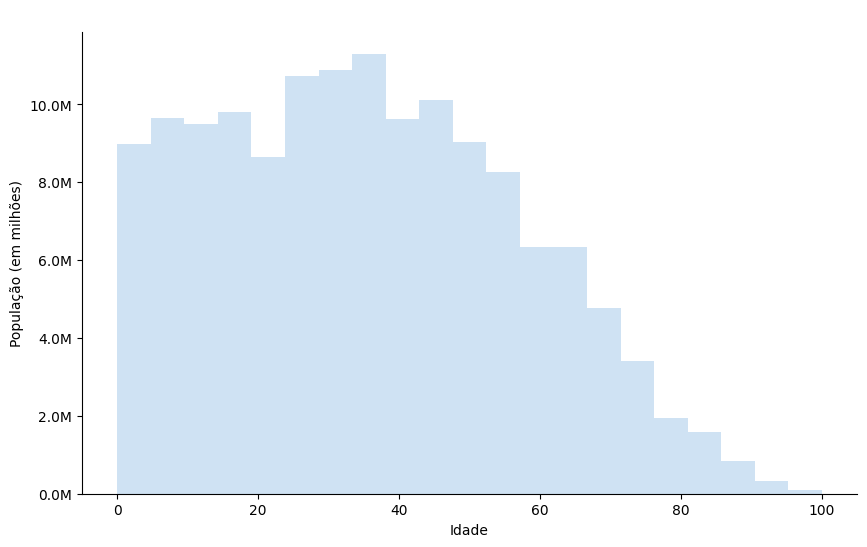

In [ ]:
import matplotlib.ticker as ticker
import numpy as np

# Calculando os bins
bins_d = np.histogram_bin_edges(amostra['IDADE'], bins='doane')

fig, ax = plt.subplots(figsize=(10, 6))

# Plotando o histograma
ax.hist(amostra['IDADE'], bins=bins_d, weights=amostra['TOTAL'], color='#cfe2f3', linewidth=0.5)

# 🔹 FORMATADOR DO EIXO Y: Divide o valor por 1.000.000 e adiciona 'M' ou apenas formata
# x é o valor original, pos é a posição (necessário para o FuncFormatter)
formatter = ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
ax.yaxis.set_major_formatter(formatter)

# Ajustes de labels e título
ax.set_xlabel('Idade')
ax.set_ylabel('População (em milhões)')
ax.set_title(' ')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

**Histograma separado por sexo**

2.1. histograma de cima, separado entre os sexos.

In [ ]:
# separando por sexo
homens = amostra[amostra['SEXO'] == 'Homens']
mulheres = amostra[amostra['SEXO'] == 'Mulheres']

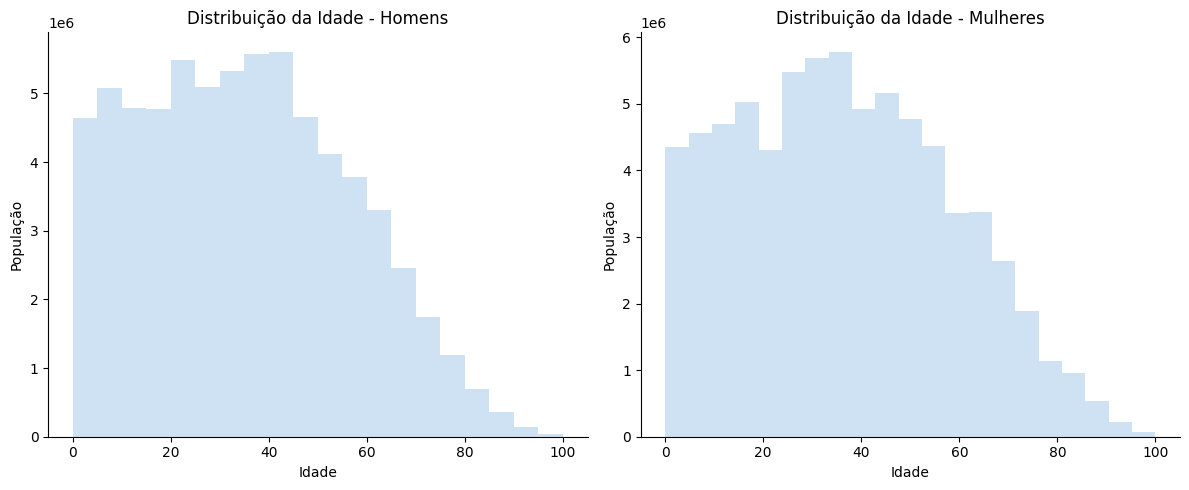

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# HOMENS
bins_h = np.histogram_bin_edges(homens['IDADE'], bins='doane')

axes[0].hist(
    homens['IDADE'],
    bins=bins_h,
    weights=homens['TOTAL'],
    color='#cfe2f3'
)

axes[0].set_title('Distribuição da Idade - Homens')
axes[0].set_xlabel('Idade')
axes[0].set_ylabel('População')

# MULHERES
bins_m = np.histogram_bin_edges(mulheres['IDADE'], bins='doane')

axes[1].hist(
    mulheres['IDADE'],
    bins=bins_m,
    weights=mulheres['TOTAL'],
    color='#cfe2f3'
)

axes[1].set_title('Distribuição da Idade - Mulheres')
axes[1].set_xlabel('Idade')
axes[1].set_ylabel('População')

# remover bordas
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Colocando o eixo x em escala de milhão**

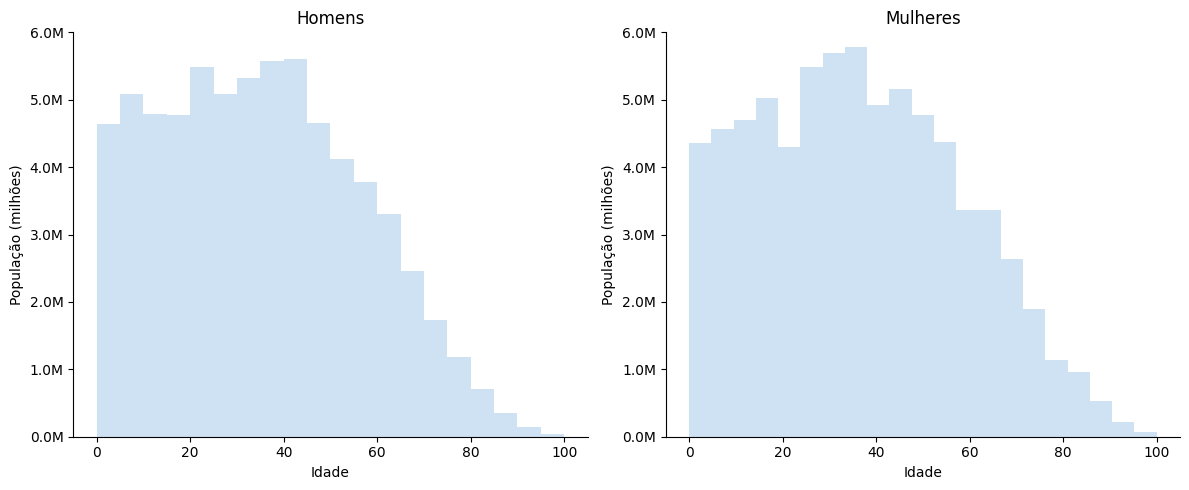

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

import matplotlib.ticker as ticker
formatter = ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')

# HOMENS
bins_h = np.histogram_bin_edges(homens['IDADE'], bins='doane')
axes[0].hist(
    homens['IDADE'],
    bins=bins_h,
    weights=homens['TOTAL'],
    color='#cfe2f3',
    linewidth=0.5
)
axes[0].set_title('Homens')
axes[0].set_xlabel('Idade')
axes[0].set_ylabel('População (milhões)')
axes[0].yaxis.set_major_formatter(formatter)
axes[0].set_ylim(0, 6e6)  #  limite do eixo y

# MULHERES
bins_m = np.histogram_bin_edges(mulheres['IDADE'], bins='doane')
axes[1].hist(
    mulheres['IDADE'],
    bins=bins_m,
    weights=mulheres['TOTAL'],
    color='#cfe2f3',
    linewidth=0.5
)
axes[1].set_title('Mulheres')
axes[1].set_xlabel('Idade')
axes[1].set_ylabel('População (milhões)')
axes[1].yaxis.set_major_formatter(formatter)
axes[1].set_ylim(0, 6e6)  #  mesmo limite do eixo y

# remover bordas
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**boxplot**

/tmp/ipykernel_25520/2589640322.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([idades_h, idades_m], labels=['Homens', 'Mulheres'])


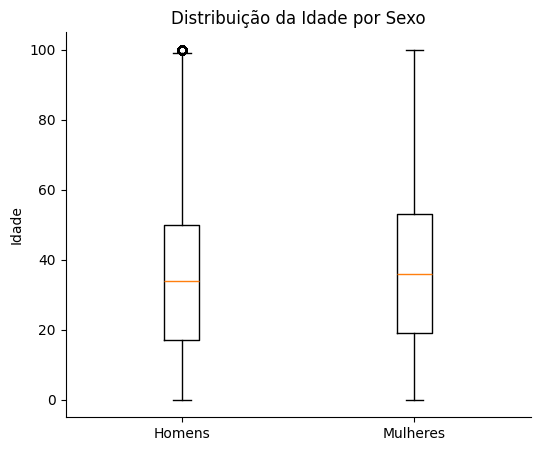

In [ ]:
def expandir_idade(df):
    return np.repeat(df['IDADE'].values, df['TOTAL'].values)

idades_h = expandir_idade(homens)
idades_m = expandir_idade(mulheres)

fig, ax = plt.subplots(figsize=(6,5))

ax.boxplot([idades_h, idades_m], labels=['Homens', 'Mulheres'])

ax.set_title('Distribuição da Idade por Sexo')
ax.set_ylabel('Idade')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

**ESTATISTICA DESCRITIVA POR SEXO**

In [ ]:
def expandir(df):
    return np.repeat(df['IDADE'].values, df['TOTAL'].values)

idades_h = expandir(homens)
idades_m = expandir(mulheres)

# describe
desc_h = pd.Series(idades_h).describe().round(2)
desc_m = pd.Series(idades_m).describe().round(2)

print('Homens:\n', desc_h)
print('\nMulheres:\n', desc_m)

Homens:
 count    68850457.00
mean           34.74
std            21.17
min             0.00
25%            17.00
50%            34.00
75%            50.00
max           100.00
dtype: float64

Mulheres:
 count    73324072.00
mean           36.72
std            21.73
min             0.00
25%            19.00
50%            36.00
75%            53.00
max           100.00
dtype: float64


3. quais estados com mais pessoas idosas? (%)

In [ ]:
# total por estado
total_estado = amostra.groupby('SG_UF')['TOTAL'].sum()

In [ ]:
# idosos por estado (>= 60)
idosos = amostra[amostra['IDADE'] >= 60]
idosos_estado = idosos.groupby('SG_UF')['TOTAL'].sum()

# percentual
perc_idosos = (idosos_estado / total_estado) * 100

# top 5
top10_idosos = perc_idosos.sort_values(ascending=False).head(5)

print(top10_idosos.round(2))

SG_UF
RS    19.90
RJ    18.40
MG    17.87
SP    17.41
PR    16.62
Name: TOTAL, dtype: float64


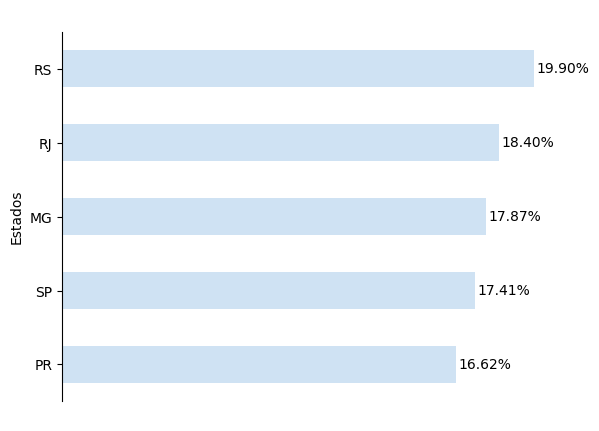

In [ ]:
ax = top10_idosos.sort_values().plot(kind='barh', color='#cfe2f3')

plt.xlabel(' ')
plt.ylabel('Estados')
plt.title(' ')

# 🔹 adicionar valores
for i, v in enumerate(top10_idosos.sort_values()):
    ax.text(v + 0.1, i, f'{v:.2f}%', va='center')

# remover bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xticks([]) #tirar os valores do eixo x

plt.show()

3.1. qual o estado com mais crianças (0 a 4)? (%)

In [ ]:
# crianças por estado (0 a 14)
crianca = amostra[amostra['IDADE'] <= 14]
crianca_estado = crianca.groupby('SG_UF')['TOTAL'].sum()

# percentual
perc_crianca = (crianca_estado / total_estado) * 100

# top 5
top5_crianca = perc_crianca.sort_values(ascending=False).head(5)

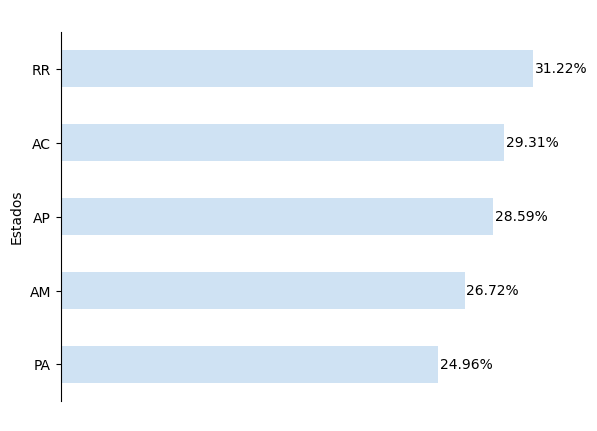

In [ ]:
ax = top5_crianca.sort_values().plot(kind='barh', color='#cfe2f3')

plt.xlabel(' ')
plt.ylabel('Estados')
plt.title(' ')

# 🔹 adicionar valores
for i, v in enumerate(top5_crianca.sort_values()):
    ax.text(v + 0.1, i, f'{v:.2f}%', va='center')

# remover bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xticks([]) #tirar os valores do eixo x

plt.show()

4. qual o estado com mais pessoas em idade ativa (entre 15 e 64)? (%)

In [ ]:
from enum import Flag
# total por estado
total_estado = amostra.groupby('SG_UF')['TOTAL'].sum()

# população em idade ativa
ativa = amostra[(amostra['IDADE'] >= 15) & (amostra['IDADE'] <= 64)]
ativa_estado = ativa.groupby('SG_UF')['TOTAL'].sum()

# percentual
perc_ativa = (ativa_estado / total_estado) * 100

# top 10
top10_ativa = perc_ativa.sort_values(ascending=False).head(10)

print(top10_ativa.round(2))

SG_UF
DF    72.53
SC    71.12
GO    70.69
ES    70.57
RN    70.55
MT    70.44
SP    70.31
MG    70.13
RO    69.43
CE    69.40
Name: TOTAL, dtype: float64


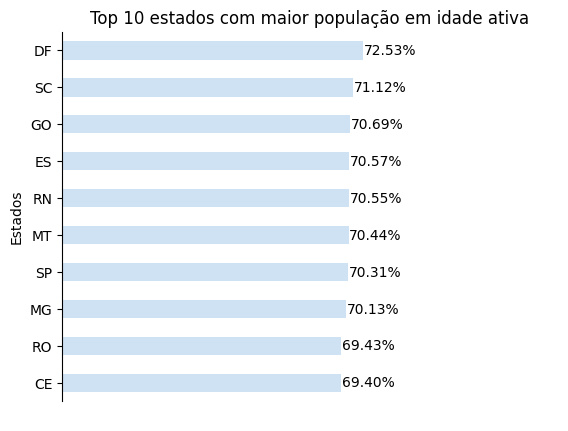

In [ ]:
ax = top10_ativa.sort_values().plot(kind='barh', color='#cfe2f3')

plt.xlabel(' ')
plt.ylabel('Estados')
plt.title('Top 10 estados com maior população em idade ativa')

# limitar o eixo x
plt.xlim(30, 100)

# valores nas barras
for i, v in enumerate(top10_ativa.sort_values()):
    ax.text(v + 0.1, i, f'{v:.2f}%', va='center')

# remover bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.set_xticks([]) #tirar os valores do eixo x

plt.show()

5. qual a região mais populosa (df.describe dessa região)?

In [ ]:
pop_regiao = amostra.groupby('NO_REGIAO')['TOTAL'].sum()

pop_regiao.sort_values(ascending=False)

,TOTAL
NO_REGIAO,
Sudeste,58974088
Nordeste,38341012
Sul,20955355
Norte,12391364
Centro-Oeste,11512710


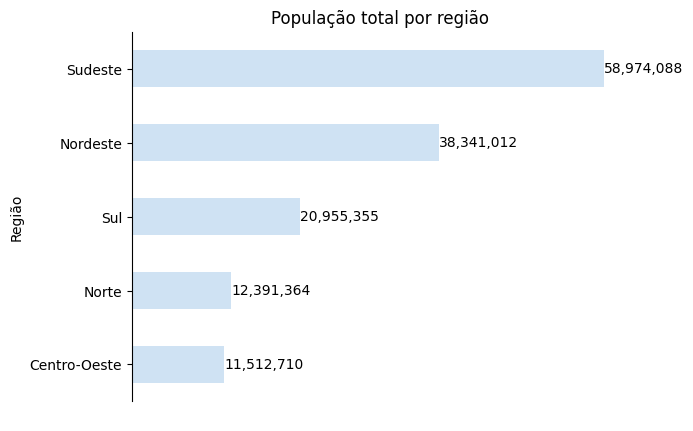

In [ ]:
ax = pop_regiao.sort_values().plot(kind='barh', color='#cfe2f3')

plt.xlabel(' ')
plt.ylabel('Região')
plt.title('População total por região')

# valores nas barras
for i, v in enumerate(pop_regiao.sort_values()):
    ax.text(v, i, f'{int(v):,}', va='center')

# remover bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xticks([]) #tirar os valores do eixo x

plt.show()

6. o número de pessoas idosas segue a proporção geral entre os sexos?


In [ ]:
abs_sexo = amostra.groupby('SEXO')['TOTAL'].sum()
rel_sexo = abs_sexo / abs_sexo.sum() * 100

tabela = pd.DataFrame({
    'Absoluto': abs_sexo,
    'Percentual (%)': rel_sexo
})

print(tabela.round(2))

          Absoluto  Percentual (%)
SEXO                              
Homens    68850457           48.43
Mulheres  73324072           51.57


In [ ]:
idosos = amostra[amostra['IDADE'] >= 60]

idosos_sexo = idosos.groupby('SEXO')['TOTAL'].sum()
prop_idosos = (idosos_sexo / idosos_sexo.sum()) * 100

idosos_sexo = idosos.groupby('SEXO')['TOTAL'].sum()
prop_idosos = (idosos_sexo / idosos_sexo.sum()) * 100

tabela = pd.DataFrame({
    'Absoluto': idosos_sexo,
    'Percentual (%)': prop_idosos
})

print(tabela.round(2))

          Absoluto  Percentual (%)
SEXO                              
Homens     9921887           44.46
Mulheres  12394119           55.54


In [ ]:
print(idosos['TOTAL'].sum())

22316006


9. qual a cidade mais populosa?

In [ ]:
pop_municipio = amostra.groupby('NO_MUNICIPIO')['TOTAL'].sum()

cidade_mais_populosa = pop_municipio.sort_values(ascending=False).head(3)

print(cidade_mais_populosa)

NO_MUNICIPIO
São Paulo         7745376
Rio de Janeiro    4269070
Brasília          2039965
Name: TOTAL, dtype: int64


10. índice de envelhecimento populacional: (idosos/crianças)

In [ ]:
# jovens (0–14)
jovens = amostra[(amostra['IDADE'] >= 0) & (amostra['IDADE'] <= 14)]
pop_jovem = jovens['TOTAL'].sum()

# idosos (≥ 60)
idosos = amostra[amostra['IDADE'] >= 60]
pop_idosa = idosos['TOTAL'].sum()

indice_envelhecimento = (pop_idosa / pop_jovem) * 100

print(f'Índice de envelhecimento: {indice_envelhecimento:.2f}')

Índice de envelhecimento: 79.35


11. indice por região

In [ ]:
# jovens (0–14)
jovens = amostra[(amostra['IDADE'] >= 0) & (amostra['IDADE'] <= 14)]
jovens_reg = jovens.groupby('NO_REGIAO')['TOTAL'].sum()

# idosos (≥ 60)
idosos = amostra[amostra['IDADE'] >= 60]
idosos_reg = idosos.groupby('NO_REGIAO')['TOTAL'].sum()

# índice de envelhecimento
indice_regiao = (idosos_reg / jovens_reg) * 100

print(indice_regiao.round(2))

NO_REGIAO
Centro-Oeste    62.34
Nordeste        66.94
Norte           40.64
Sudeste         99.14
Sul             93.66
Name: TOTAL, dtype: float64


12. percentual em cada faixa etária por regiao

percentuais por regiao

In [ ]:
# jovens (0–14)
jovens = amostra[(amostra['IDADE'] >= 0) & (amostra['IDADE'] <= 14)]
jovens_reg = jovens.groupby('NO_REGIAO')['TOTAL'].sum()

# ativa (15–64)
ativa = amostra[(amostra['IDADE'] >= 15) & (amostra['IDADE'] <= 64)]
ativa_reg = ativa.groupby('NO_REGIAO')['TOTAL'].sum()

# idosos (≥ 65)
idosos = amostra[amostra['IDADE'] >= 65]
idosos_reg = idosos.groupby('NO_REGIAO')['TOTAL'].sum()

# total por região
total_reg = amostra.groupby('NO_REGIAO')['TOTAL'].sum()

# percentuais
perc_jovens = (jovens_reg / total_reg) * 100
perc_ativa = (ativa_reg / total_reg) * 100
perc_idosos = (idosos_reg / total_reg) * 100

/tmp/ipykernel_25520/2819200846.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(perc_jovens[i]/2, i, f'{perc_jovens[i]:.1f}', ha='center', va='center', color='white')
/tmp/ipykernel_25520/2819200846.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(perc_jovens[i] + perc_ativa[i]/2, i, f'{perc_ativa[i]:.1f}', ha='center', va='center', color='white')
/tmp/ipykernel_25520/2819200846.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position

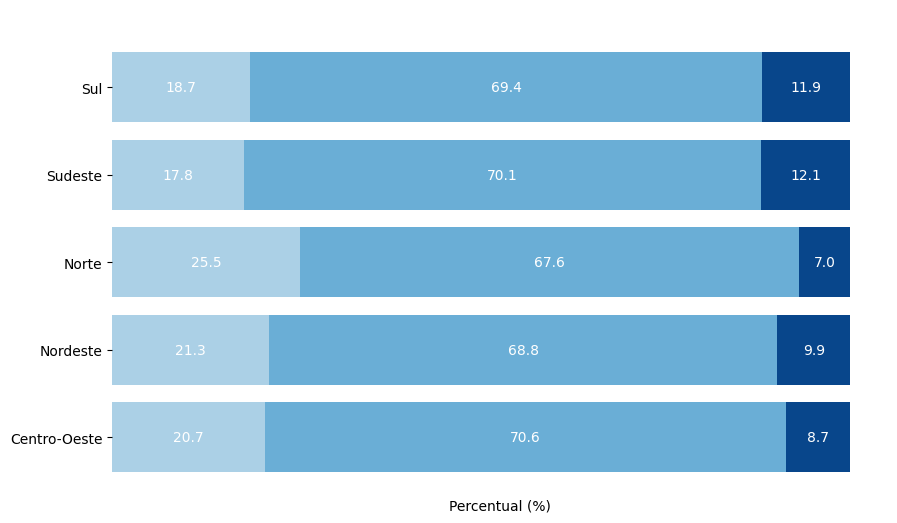

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

# ordem das regiões
regioes = perc_jovens.index

# barras empilhadas
ax.barh(regioes, perc_jovens, color='#ABD0E6', label='0–14')
ax.barh(regioes, perc_ativa, left=perc_jovens, color='#6AAED6', label='15–59')
ax.barh(regioes, perc_idosos, left=perc_jovens + perc_ativa, color='#08468B', label='60+')

# adicionar valores dentro das barras
for i in range(len(regioes)):
    ax.text(perc_jovens[i]/2, i, f'{perc_jovens[i]:.1f}', ha='center', va='center', color='white')

    ax.text(perc_jovens[i] + perc_ativa[i]/2, i, f'{perc_ativa[i]:.1f}', ha='center', va='center', color='white')

    ax.text(perc_jovens[i] + perc_ativa[i] + perc_idosos[i]/2, i, f'{perc_idosos[i]:.1f}', ha='center', va='center', color='white')

# ajustes
ax.set_xlabel('Percentual (%)')
ax.set_title(' ')
ax.get_legend() # tirar legenda


# remover bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xticks([]) #tirar os valores do eixo x

plt.show()

# **MAPA DA IDADE MEDIANA**

In [ ]:
pip install geobr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.0/338.0 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 45.2 MB/s eta 0:00:00
  Attempting uninstall: shapely
    Found existing installation: shapely 2.1.2
    Uninstalling shapely-2.1.2:
      Successfully uninstalled shapely-2.1.2
  Attempting uninstall: lxml
    Found existing installation: lxml 6.0.2
    Uninstalling lxml-6.0.2:
      Successfully uninstalled lxml-6.0.2
  Attempting uninstall: geopandas
    Found existing installation: geopandas 1.1.3
    Uninstalling geopandas-1.1.3:
      Successfully uninstalled geopandas-1.1.3


In [ ]:
def mediana_ponderada(grupo):
    valores = grupo['IDADE']
    pesos = grupo['TOTAL']

    ordem = np.argsort(valores)
    valores = valores.iloc[ordem]
    pesos = pesos.iloc[ordem]

    acumulado = pesos.cumsum()
    metade = pesos.sum() / 2

    return valores[acumulado >= metade].iloc[0]

# calcular por estado
mediana_estado = amostra.groupby('SG_UF').apply(mediana_ponderada)
mediana_estado = mediana_estado.reset_index()
mediana_estado.columns = ['SG_UF', 'mediana_idade']

/tmp/ipykernel_25520/2827759338.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mediana_estado = amostra.groupby('SG_UF').apply(mediana_ponderada)


Carregando o mapa do Brasil (por estados)

In [ ]:
import geobr
import geopandas as gpd

# baixar mapa dos estados automaticamente
mapa = geobr.read_state(year=2020)

In [ ]:
mapa.head(10)

,code_state,abbrev_state,name_state,code_region,name_region,geometry
0,11.0,RO,Rondônia,1.0,Norte,"MULTIPOLYGON (((-65.3815 -10.42907, -65.38013 ..."
1,12.0,AC,Acre,1.0,Norte,"MULTIPOLYGON (((-71.07772 -9.82774, -71.07817 ..."
2,13.0,AM,Amazônas,1.0,Norte,"MULTIPOLYGON (((-69.83766 -3.68659, -69.82555 ..."
3,14.0,RR,Roraima,1.0,Norte,"MULTIPOLYGON (((-63.96008 2.47313, -63.96041 2..."
4,15.0,PA,Pará,1.0,Norte,"MULTIPOLYGON (((-51.43248 -0.47334, -51.42949 ..."
5,16.0,AP,Amapá,1.0,Norte,"MULTIPOLYGON (((-50.45011 2.10924, -50.44715 2..."
6,17.0,TO,Tocantins,1.0,Norte,"MULTIPOLYGON (((-48.23291 -5.94757, -48.23163 ..."
7,21.0,MA,Maranhão,2.0,Nordeste,"MULTIPOLYGON (((-44.9662 -1.27114, -44.96081 -..."
8,22.0,PI,Piauí,2.0,Nordeste,"MULTIPOLYGON (((-42.91509 -6.64795, -42.91636 ..."
9,23.0,CE,Ceará,2.0,Nordeste,"MULTIPOLYGON (((-41.18292 -4.01797, -41.18552 ..."


Fazendo o join

In [ ]:
mapa = mapa.merge(mediana_estado, left_on='abbrev_state', right_on='SG_UF')

In [ ]:
mapa.head(10)

,code_state,abbrev_state,name_state,code_region,name_region,geometry,SG_UF,mediana_idade
0,11.0,RO,Rondônia,1.0,Norte,"MULTIPOLYGON (((-65.3815 -10.42907, -65.38013 ...",RO,32
1,12.0,AC,Acre,1.0,Norte,"MULTIPOLYGON (((-71.07772 -9.82774, -71.07817 ...",AC,27
2,13.0,AM,Amazônas,1.0,Norte,"MULTIPOLYGON (((-69.83766 -3.68659, -69.82555 ...",AM,27
3,14.0,RR,Roraima,1.0,Norte,"MULTIPOLYGON (((-63.96008 2.47313, -63.96041 2...",RR,26
4,15.0,PA,Pará,1.0,Norte,"MULTIPOLYGON (((-51.43248 -0.47334, -51.42949 ...",PA,29
5,16.0,AP,Amapá,1.0,Norte,"MULTIPOLYGON (((-50.45011 2.10924, -50.44715 2...",AP,28
6,17.0,TO,Tocantins,1.0,Norte,"MULTIPOLYGON (((-48.23291 -5.94757, -48.23163 ...",TO,31
7,21.0,MA,Maranhão,2.0,Nordeste,"MULTIPOLYGON (((-44.9662 -1.27114, -44.96081 -...",MA,30
8,22.0,PI,Piauí,2.0,Nordeste,"MULTIPOLYGON (((-42.91509 -6.64795, -42.91636 ...",PI,34
9,23.0,CE,Ceará,2.0,Nordeste,"MULTIPOLYGON (((-41.18292 -4.01797, -41.18552 ...",CE,33


Tirando abbrev_state, pq se repete em SG_UF

In [ ]:
mapa.columns

Index(['code_state', 'abbrev_state', 'name_state', 'code_region',
       'name_region', 'geometry', 'SG_UF', 'mediana_idade'],
      dtype='object')

In [ ]:
colunas = ['code_state', 'name_state', 'code_region',
       'name_region', 'geometry', 'SG_UF', 'mediana_idade']

In [ ]:
mapa = mapa[colunas]

**Plotando o mapa**

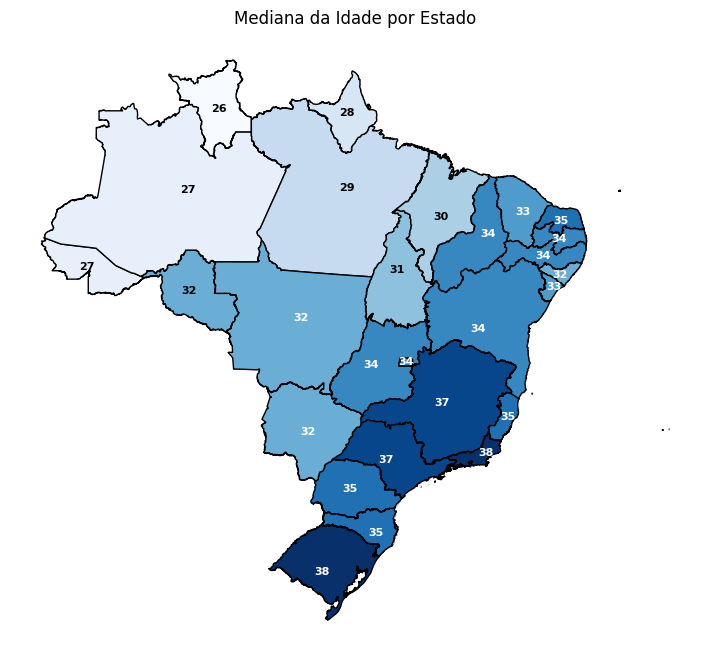

In [ ]:
fig, ax = plt.subplots(figsize=(10,8))

# 1. Definir a lista de siglas da região Norte + MA
estados_norte = ['AC', 'AM', 'AP', 'PA', 'RO', 'RR', 'TO', 'MA']

# Plotagem do mapa
mapa.plot(
    column='mediana_idade',
    cmap='Blues',
    edgecolor='black',
    legend=False,
    ax=ax
)

# Ponto representativo para os rótulos
mapa['centroide'] = mapa.geometry.representative_point()

# Adicionar valores com a lógica solicitada
for idx, row in mapa.iterrows():
    x = row['centroide'].x
    y = row['centroide'].y

    # 🔹 Lógica de cor baseada na região
    # Ajuste 'sigla' para o nome da coluna de UF no seu arquivo
    cor = 'black' if row['SG_UF'] in estados_norte else 'white'

    ax.text(
        x, y,
        f"{row['mediana_idade']:.0f}",
        ha='center',
        va='center',
        fontsize=8,
        color=cor,
        weight='bold'  #  Aplica o negrito em todos
    )

# Ajustes finais
ax.set_title('Mediana da Idade por Estado')
ax.axis('off')

plt.show()

# **MAPA DO INDICE DE ENVELHECIMENTO**


**Calculando o índice por região**

In [ ]:
# jovens (0–14)
jovens = amostra[(amostra['IDADE'] >= 0) & (amostra['IDADE'] <= 14)]
jovens_reg = jovens.groupby('NO_REGIAO')['TOTAL'].sum()

# idosos (≥ 60)
idosos = amostra[amostra['IDADE'] >= 60]
idosos_reg = idosos.groupby('NO_REGIAO')['TOTAL'].sum()

# índice
indice_regiao = (idosos_reg / jovens_reg) * 100

# transformar em DataFrame
indice_regiao = indice_regiao.reset_index()
indice_regiao.columns = ['NO_REGIAO', 'indice_envelhecimento']

**Mapa das regiões**

In [ ]:
mapa_regiao = geobr.read_region(year=2020)

**CONFRIMANDO QUE OS VALORES DAS COLUNAS BASE DO MERGE ESTÃO IGUAIS**

repare que em mapa_regiao tem 'Centro Oeste' e em indice_regiao é tem 'Centro-Oeste'

Isso faz com que o centro-oeste suma no merge e do mapa também

In [ ]:
mapa_regiao.columns

Index(['code_region', 'name_region', 'geometry'], dtype='object')

In [ ]:
mapa_regiao['name_region'].unique()

array(['Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro Oeste'],
      dtype=object)

In [ ]:
indice_regiao.columns

Index(['NO_REGIAO', 'indice_envelhecimento'], dtype='object')

In [ ]:
indice_regiao['NO_REGIAO'].unique()

array(['Centro-Oeste', 'Nordeste', 'Norte', 'Sudeste', 'Sul'],
      dtype=object)

**Corrigindo o nome divergente**

In [ ]:
mapa_regiao['name_region'] = mapa_regiao['name_region'].replace({
    'Centro Oeste': 'Centro-Oeste'
})

**Confirmando**

In [ ]:
print(mapa_regiao['name_region'].unique())
print(indice_regiao['NO_REGIAO'].unique())

['Norte' 'Nordeste' 'Sudeste' 'Sul' 'Centro-Oeste']
['Centro-Oeste' 'Nordeste' 'Norte' 'Sudeste' 'Sul']


**Join entre mapa_regiao e indice_regiao**

In [ ]:
mapa_regiao = mapa_regiao.merge(
    indice_regiao,
    left_on='name_region',
    right_on='NO_REGIAO'
)

In [ ]:
mapa_regiao.columns

Index(['code_region', 'name_region', 'geometry', 'NO_REGIAO',
       'indice_envelhecimento'],
      dtype='object')

**Tirar a coluna repetida das regiões**

In [ ]:
colunas_regiao = ['code_region', 'geometry', 'NO_REGIAO','indice_envelhecimento']

mapa_regiao = mapa_regiao[colunas_regiao]

**Plotando mapa**

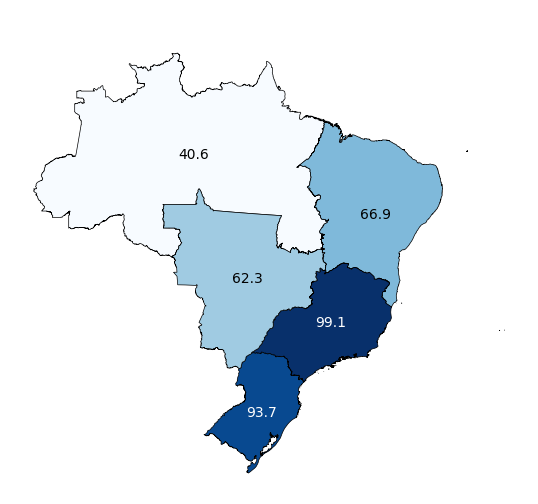

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))

#plotar o mapa
mapa_regiao.plot(
    column='indice_envelhecimento',
    cmap='Blues',
    edgecolor='black',
    linewidth=0.5,
    legend=False,
    ax=ax
)

# ponto interno
mapa_regiao['centroide'] = mapa_regiao.geometry.representative_point()

# limiar pra cor do texto
limiar = mapa_regiao['indice_envelhecimento'].median()

# valores no mapa
for idx, row in mapa_regiao.iterrows():
    x = row['centroide'].x
    y = row['centroide'].y

    cor = 'white' if row['indice_envelhecimento'] > limiar else 'black'

    ax.text(
        x, y,
        f"{row['indice_envelhecimento']:.1f}",
        ha='center',
        va='center',
        fontsize=10,
        color=cor
    )

# ajustes
ax.set_title(' ')
ax.axis('off')

plt.show()

In [ ]:
mapa_regiao['NO_REGIAO'].unique()

array(['Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-Oeste'],
      dtype=object)

**CORRELAÇÃO**

In [ ]:
# total
total_estado = amostra.groupby('SG_UF')['TOTAL'].sum()

# crianças
criancas = amostra[(amostra['IDADE'] >= 0) & (amostra['IDADE'] <= 14)]
criancas_est = criancas.groupby('SG_UF')['TOTAL'].sum()
perc_criancas = (criancas_est / total_estado) * 100

# idosos
idosos = amostra[amostra['IDADE'] >= 60]
idosos_est = idosos.groupby('SG_UF')['TOTAL'].sum()
perc_idosos = (idosos_est / total_estado) * 100

# juntar
df_corr = pd.DataFrame({
    'perc_criancas': perc_criancas,
    'perc_idosos': perc_idosos
}).dropna()

In [ ]:
corr = df_corr['perc_criancas'].corr(df_corr['perc_idosos'])
print(corr)

-0.8929983470236217


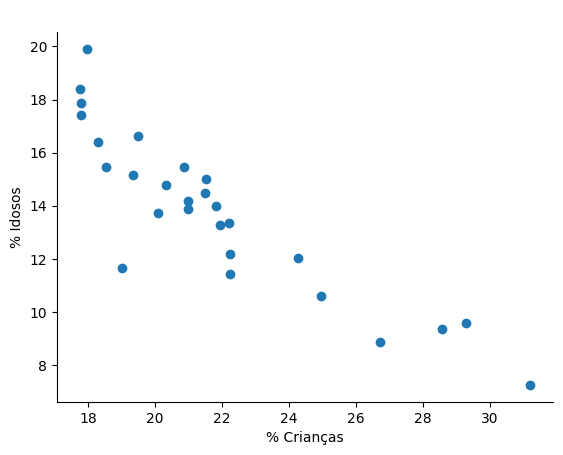

In [ ]:
fig, ax = plt.subplots()

ax.scatter(df_corr['perc_criancas'], df_corr['perc_idosos'])

ax.set_xlabel('% Crianças')
ax.set_ylabel('% Idosos')
ax.set_title(' ')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()
plt.show()

In [ ]:
df_corr['indice_relacao'] = df_corr['perc_idosos'] - df_corr['perc_criancas']